<a href="https://colab.research.google.com/github/maryammahmood371-cell/E-Signing-of-customer-on-financial-data/blob/main/E_Signing_of_customer_on_financial_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Project: Financial Loan E-Signing Prediction Pipeline

In [4]:
# Dataset link:https://www.kaggle.com/datasets/aniruddhachoudhury/esigning-of-loan-based-on-financial-history

## 1. Initial Preparation

In [87]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, roc_auc_score
from xgboost import XGBClassifier

##1.1 Load dataset

In [88]:
df=pd.read_csv('/content/financial_data.csv.zip')

In [89]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)

##1.2 Initial analysis

In [90]:
df.head()

,entry_id,age,pay_schedule,home_owner,income,months_employed,years_employed,current_address_year,personal_account_m,personal_account_y,has_debt,amount_requested,risk_score,risk_score_2,risk_score_3,risk_score_4,risk_score_5,ext_quality_score,ext_quality_score_2,inquiries_last_month,e_signed
0,7629673,40,bi-weekly,1,3135,0,3,3,6,2,1,550,36200,0.737398,0.903517,0.487712,0.515977,0.580918,0.380918,10,1
1,3560428,61,weekly,0,3180,0,6,3,2,7,1,600,30150,0.738510,0.881027,0.713423,0.826402,0.730720,0.630720,9,0
2,6934997,23,weekly,0,1540,6,0,0,7,1,1,450,34550,0.642993,0.766554,0.595018,0.762284,0.531712,0.531712,7,0
3,5682812,40,bi-weekly,0,5230,0,6,1,2,7,1,700,42150,0.665224,0.960832,0.767828,0.778831,0.792552,0.592552,8,1
4,5335819,33,semi-monthly,0,3590,0,5,2,2,8,1,1100,53850,0.617361,0.857560,0.613487,0.665523,0.744634,0.744634,12,0


In [91]:
df.shape

(17908, 21)

In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17908 entries, 0 to 17907
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   entry_id              17908 non-null  int64  
 1   age                   17908 non-null  int64  
 2   pay_schedule          17908 non-null  object 
 3   home_owner            17908 non-null  int64  
 4   income                17908 non-null  int64  
 5   months_employed       17908 non-null  int64  
 6   years_employed        17908 non-null  int64  
 7   current_address_year  17908 non-null  int64  
 8   personal_account_m    17908 non-null  int64  
 9   personal_account_y    17908 non-null  int64  
 10  has_debt              17908 non-null  int64  
 11  amount_requested      17908 non-null  int64  
 12  risk_score            17908 non-null  int64  
 13  risk_score_2          17908 non-null  float64
 14  risk_score_3          17908 non-null  float64
 15  risk_score_4       

In [93]:
df.pay_schedule.unique()

array(['bi-weekly', 'weekly', 'semi-monthly', 'monthly'], dtype=object)

## 2. Preparation for exploratory data analysis(EDA)

##2.1 Convert Personal Account Time Length

In [94]:
df = df_raw.copy() # Re-initialize df to ensure it has the original columns
df['total_months_personal_account'] = (df['personal_account_y'] * 12) + df['personal_account_m']
df = df.drop(columns=['personal_account_y', 'personal_account_m'])

In [95]:
df.head()

,entry_id,age,pay_schedule,home_owner,income,months_employed,years_employed,current_address_year,has_debt,amount_requested,risk_score,risk_score_2,risk_score_3,risk_score_4,risk_score_5,ext_quality_score,ext_quality_score_2,inquiries_last_month,e_signed,total_months_personal_account
0,7629673,40,bi-weekly,1,3135,0,3,3,1,550,36200,0.737398,0.903517,0.487712,0.515977,0.580918,0.380918,10,1,30
1,3560428,61,weekly,0,3180,0,6,3,1,600,30150,0.738510,0.881027,0.713423,0.826402,0.730720,0.630720,9,0,86
2,6934997,23,weekly,0,1540,6,0,0,1,450,34550,0.642993,0.766554,0.595018,0.762284,0.531712,0.531712,7,0,19
3,5682812,40,bi-weekly,0,5230,0,6,1,1,700,42150,0.665224,0.960832,0.767828,0.778831,0.792552,0.592552,8,1,86
4,5335819,33,semi-monthly,0,3590,0,5,2,1,1100,53850,0.617361,0.857560,0.613487,0.665523,0.744634,0.744634,12,0,98


##2.2 Convert Employed Time Length

In [28]:
df['employed_month'] = df['months_employed'] * 12 + df['years_employed']
df.drop(columns=['months_employed', 'years_employed'], inplace=True)

In [29]:
df.head()

,entry_id,age,pay_schedule,home_owner,income,current_address_year,has_debt,amount_requested,risk_score,risk_score_2,risk_score_3,risk_score_4,risk_score_5,ext_quality_score,ext_quality_score_2,inquiries_last_month,e_signed,total_months_personal_account,employed_month
0,7629673,40,bi-weekly,1,3135,3,1,550,36200,0.737398,0.903517,0.487712,0.515977,0.580918,0.380918,10,1,30,3
1,3560428,61,weekly,0,3180,3,1,600,30150,0.738510,0.881027,0.713423,0.826402,0.730720,0.630720,9,0,86,6
2,6934997,23,weekly,0,1540,0,1,450,34550,0.642993,0.766554,0.595018,0.762284,0.531712,0.531712,7,0,19,72
3,5682812,40,bi-weekly,0,5230,1,1,700,42150,0.665224,0.960832,0.767828,0.778831,0.792552,0.592552,8,1,86,6
4,5335819,33,semi-monthly,0,3590,2,1,1100,53850,0.617361,0.857560,0.613487,0.665523,0.744634,0.744634,12,0,98,5


## 2.3 Separating Variables (Numeric Or Categorical)

In [96]:
target_col = 'e_signed'
id_col = 'entry_id'

In [97]:
df.nunique()

,0
entry_id,17888
age,72
pay_schedule,4
home_owner,2
income,2284
months_employed,12
years_employed,17
current_address_year,13
has_debt,2
amount_requested,98


In [118]:
categorical_cols = [col for col in df.columns if df[col].dtype == 'O']
numeric_cols = [col for col in df.columns if col not in categorical_cols + [target_col, id_col]]

AttributeError: 'RandomForestClassifier' object has no attribute 'columns'

In [99]:
numeric_cols

['age',
 'home_owner',
 'income',
 'months_employed',
 'years_employed',
 'current_address_year',
 'has_debt',
 'amount_requested',
 'risk_score',
 'risk_score_2',
 'risk_score_3',
 'risk_score_4',
 'risk_score_5',
 'ext_quality_score',
 'ext_quality_score_2',
 'inquiries_last_month',
 'total_months_personal_account']

## 3. Exploratory Data Analysis (EDA)

## 3.1 Displots of Numerical Variables

IndexError: index 4 is out of bounds for axis 0 with size 4

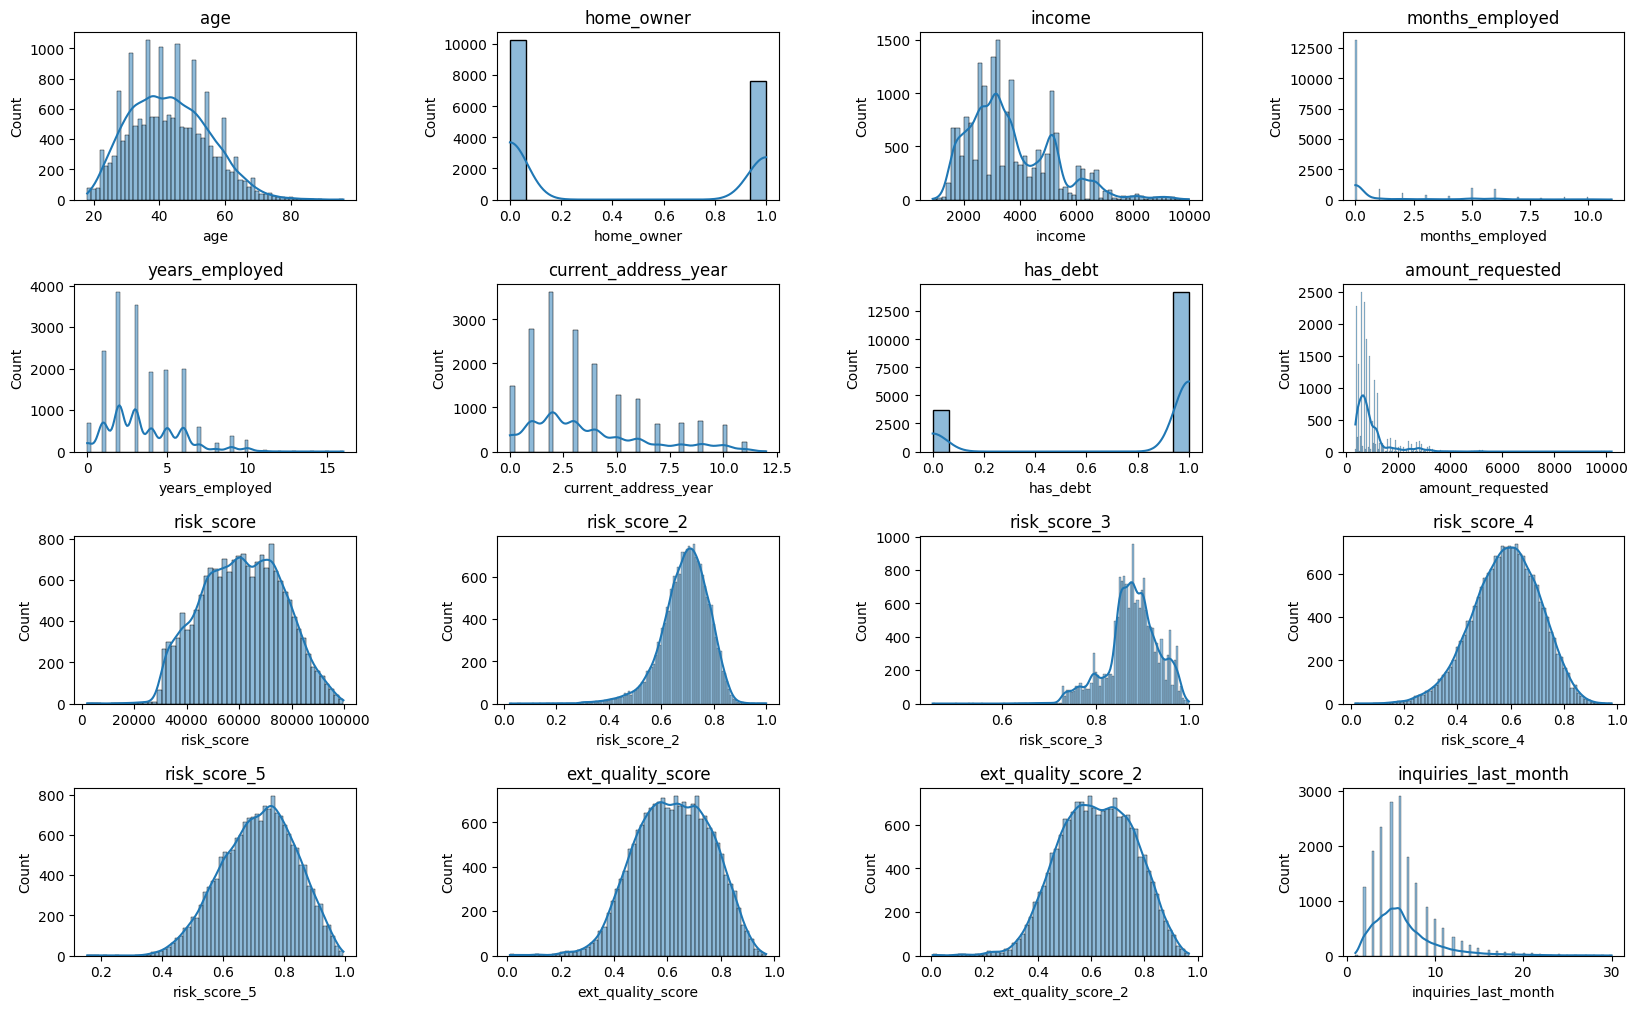

In [115]:
fig, axes = plt.subplots(4, 4, figsize=(20,12))
fig.subplots_adjust(hspace=0.5, wspace=0.5)

for i, col in enumerate(numeric_cols):
    row, col_num = divmod(i, 4)
    sns.histplot(data=df, x=col, kde=True, ax=axes[row, col_num])
    axes[row, col_num].set_title(col)

plt.show()

##3.2 Displots of Numerical Columns by Target

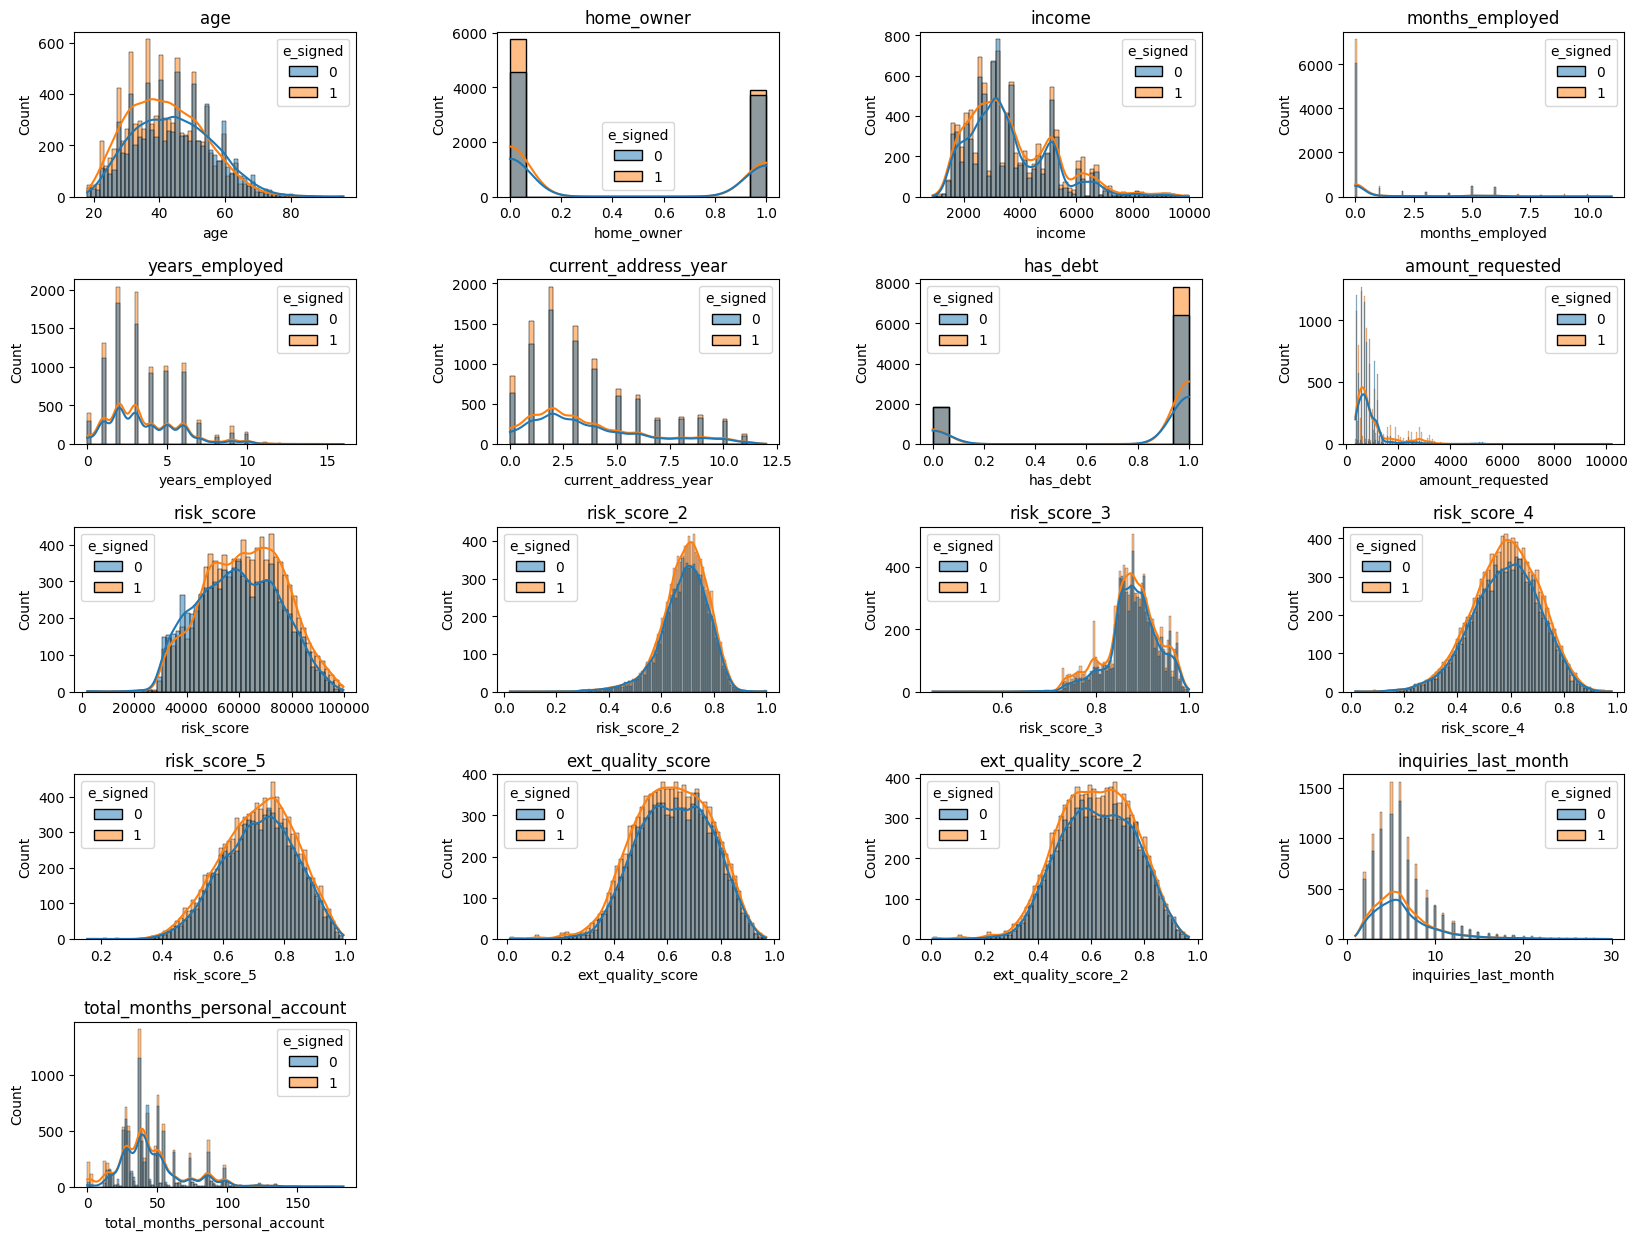

In [102]:
num_cols_to_plot = len(numeric_cols)
num_rows = (num_cols_to_plot + 3) // 4  # Calculate number of rows needed (ceil(num_cols / 4))

fig, axes = plt.subplots(num_rows, 4, figsize=(20, 3 * num_rows))
fig.subplots_adjust(hspace=0.5, wspace=0.5)

for i, col in enumerate(numeric_cols):
    row, col_num = divmod(i, 4)
    sns.histplot(data=df, x=col, kde=True, ax=axes[row, col_num], hue='e_signed')
    axes[row, col_num].set_title(col)

# Hide any unused subplots
for i in range(num_cols_to_plot, num_rows * 4):
    row, col_num = divmod(i, 4)
    fig.delaxes(axes[row, col_num])

plt.show()

##3.3 Countplots of Categorical Columns

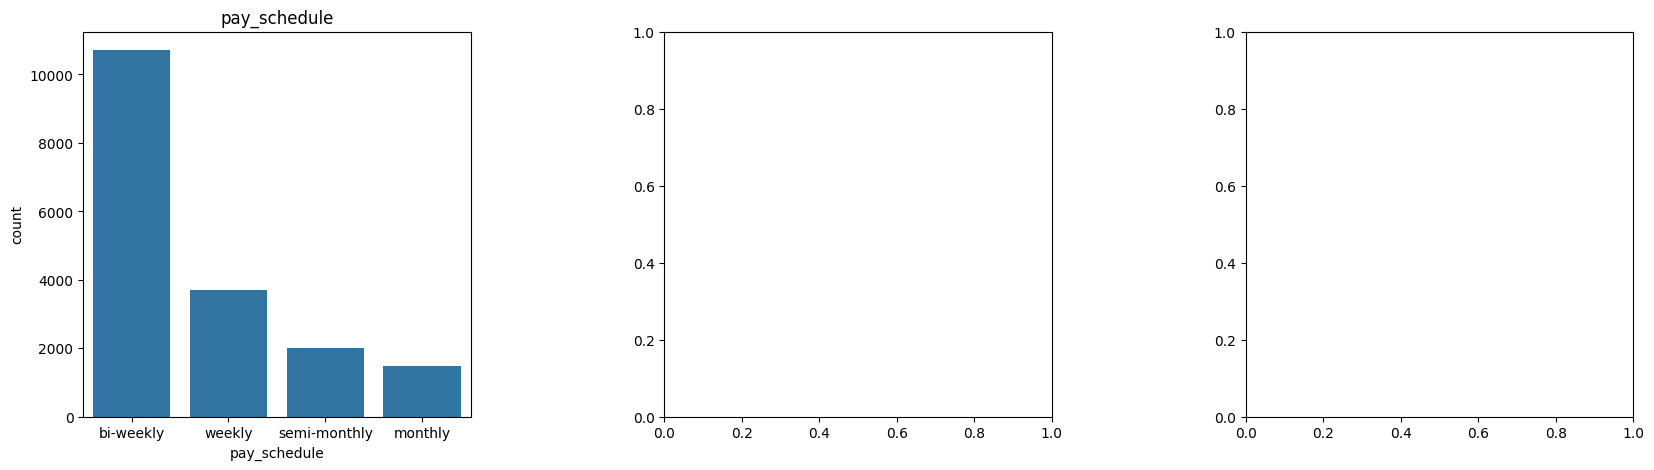

In [103]:
fig, axes = plt.subplots(1, 3, figsize=(20,5))
fig.subplots_adjust(wspace=0.5)

for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(col)

plt.show()

##3.4 Countplots of Categorical Columns by Target

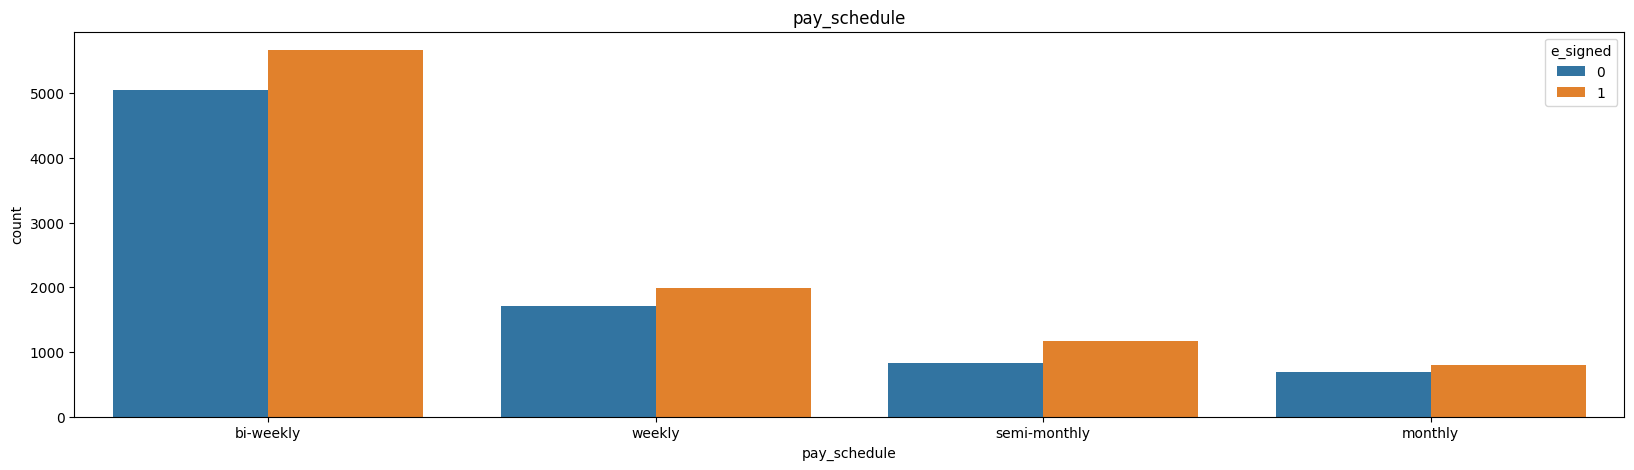

In [104]:
fig, ax = plt.subplots(1, len(categorical_cols), figsize=(20, 5))
fig.subplots_adjust(wspace=0.5)

for i, col in enumerate(categorical_cols):
    # Ensure 'ax' is iterable even if there's only one subplot
    if len(categorical_cols) == 1:
        current_ax = ax
    else:
        current_ax = ax[i]
    sns.countplot(data=df, x=col, hue='e_signed', ax=current_ax)
    current_ax.set_title(col)

plt.show()

## 3.5 Boxplots of Numerical Columns by Target

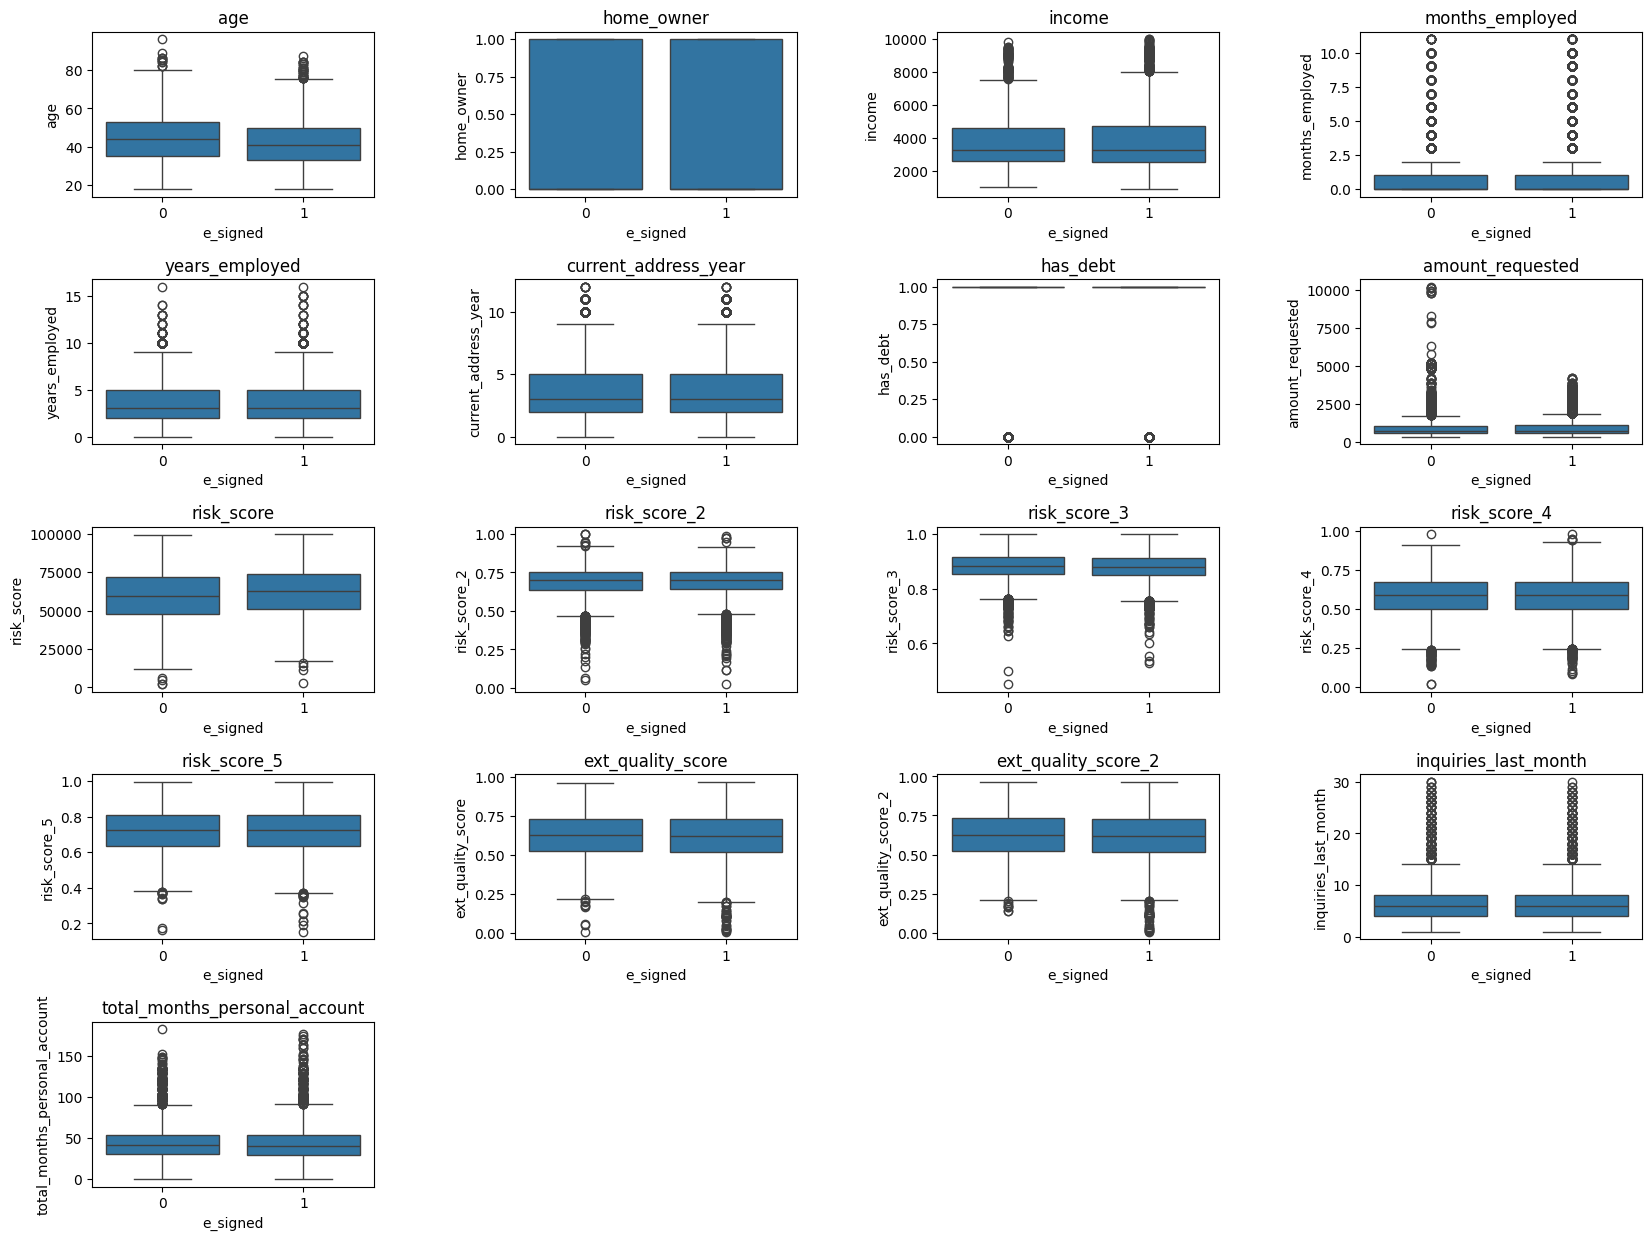

In [106]:
num_cols_to_plot = len(numeric_cols)
num_rows = (num_cols_to_plot + 3) // 4  # Calculate number of rows needed (ceil(num_cols / 4))

fig, axes = plt.subplots(num_rows, 4, figsize=(20, 3 * num_rows))
fig.subplots_adjust(hspace=0.5, wspace=0.5)

for i, col in enumerate(numeric_cols):
    row, col_num = divmod(i, 4)
    # Ensure axes[row] is a sequence if num_rows is 1, otherwise it will be a scalar
    current_ax = axes[col_num] if num_rows == 1 else axes[row, col_num]
    sns.boxplot(data=df, x='e_signed', y=col, ax=current_ax)
    current_ax.set_title(col)

# Hide any unused subplots
for i in range(num_cols_to_plot, num_rows * 4):
    row, col_num = divmod(i, 4)
    # Only try to delete if axes[row] exists and is a sequence
    if num_rows > 1:
        fig.delaxes(axes[row, col_num])
    # If num_rows is 1, axes is 1D, so just delete the single ax
    elif num_rows == 1 and col_num < len(axes):
        fig.delaxes(axes[col_num])

plt.show()

## 3.6 Repationships Between Variables (Analysis with Heatmap)

In [107]:
df_corr = pd.concat((df[numeric_cols], df[['e_signed']]), axis=1)
df_corr.corr()

,age,home_owner,income,months_employed,years_employed,current_address_year,has_debt,amount_requested,risk_score,risk_score_2,risk_score_3,risk_score_4,risk_score_5,ext_quality_score,ext_quality_score_2,inquiries_last_month,total_months_personal_account,e_signed
age,1.000000,0.142046,0.174062,-0.103635,0.182590,0.146554,-0.043808,0.084132,0.162868,-0.019163,0.111258,0.069191,0.093710,0.032265,0.040019,0.041224,0.040405,-0.096998
home_owner,0.142046,1.000000,0.147487,0.018008,0.027367,0.179291,-0.076206,0.033996,0.113608,0.000647,0.049708,-0.137293,-0.080470,0.010080,0.005507,0.011215,-0.046213,-0.047409
income,0.174062,0.147487,1.000000,-0.049157,0.102139,0.046982,-0.011199,0.289099,0.168375,-0.023627,0.058665,-0.001254,0.025179,-0.008429,-0.003323,0.051622,-0.001157,0.031377
months_employed,-0.103635,0.018008,-0.049157,1.000000,-0.189805,-0.056609,-0.000546,-0.044234,-0.044765,0.028950,-0.024297,-0.014512,-0.019406,-0.009041,-0.004461,-0.026710,0.000344,0.010128
years_employed,0.182590,0.027367,0.102139,-0.189805,1.000000,0.343905,0.005293,0.084841,0.098960,-0.056574,0.074659,-0.029398,0.000234,0.014162,0.030353,0.011976,0.181526,0.003748
current_address_year,0.146554,0.179291,0.046982,-0.056609,0.343905,1.000000,0.017423,0.067893,0.090535,-0.060412,0.058936,-0.161052,-0.094545,0.003362,0.009093,0.013659,0.119105,-0.018969
has_debt,-0.043808,-0.076206,-0.011199,-0.000546,0.005293,0.017423,1.000000,-0.008445,-0.020332,-0.034691,0.001108,0.002074,0.002341,-0.021523,-0.009055,-0.001007,-0.007454,0.039192
amount_requested,0.084132,0.033996,0.289099,-0.044234,0.084841,0.067893,-0.008445,1.000000,0.290716,0.005405,0.045465,0.061459,0.071470,0.025167,0.028052,-0.036197,0.047924,0.069572
risk_score,0.162868,0.113608,0.168375,-0.044765,0.098960,0.090535,-0.020332,0.290716,1.000000,0.208188,0.104861,0.120234,0.130464,0.098649,0.108170,-0.261076,0.013017,0.086098
risk_score_2,-0.019163,0.000647,-0.023627,0.028950,-0.056574,-0.060412,-0.034691,0.005405,0.208188,1.000000,0.184249,0.225259,0.227510,0.207386,0.200195,-0.214013,0.025542,0.010473


<Axes: >

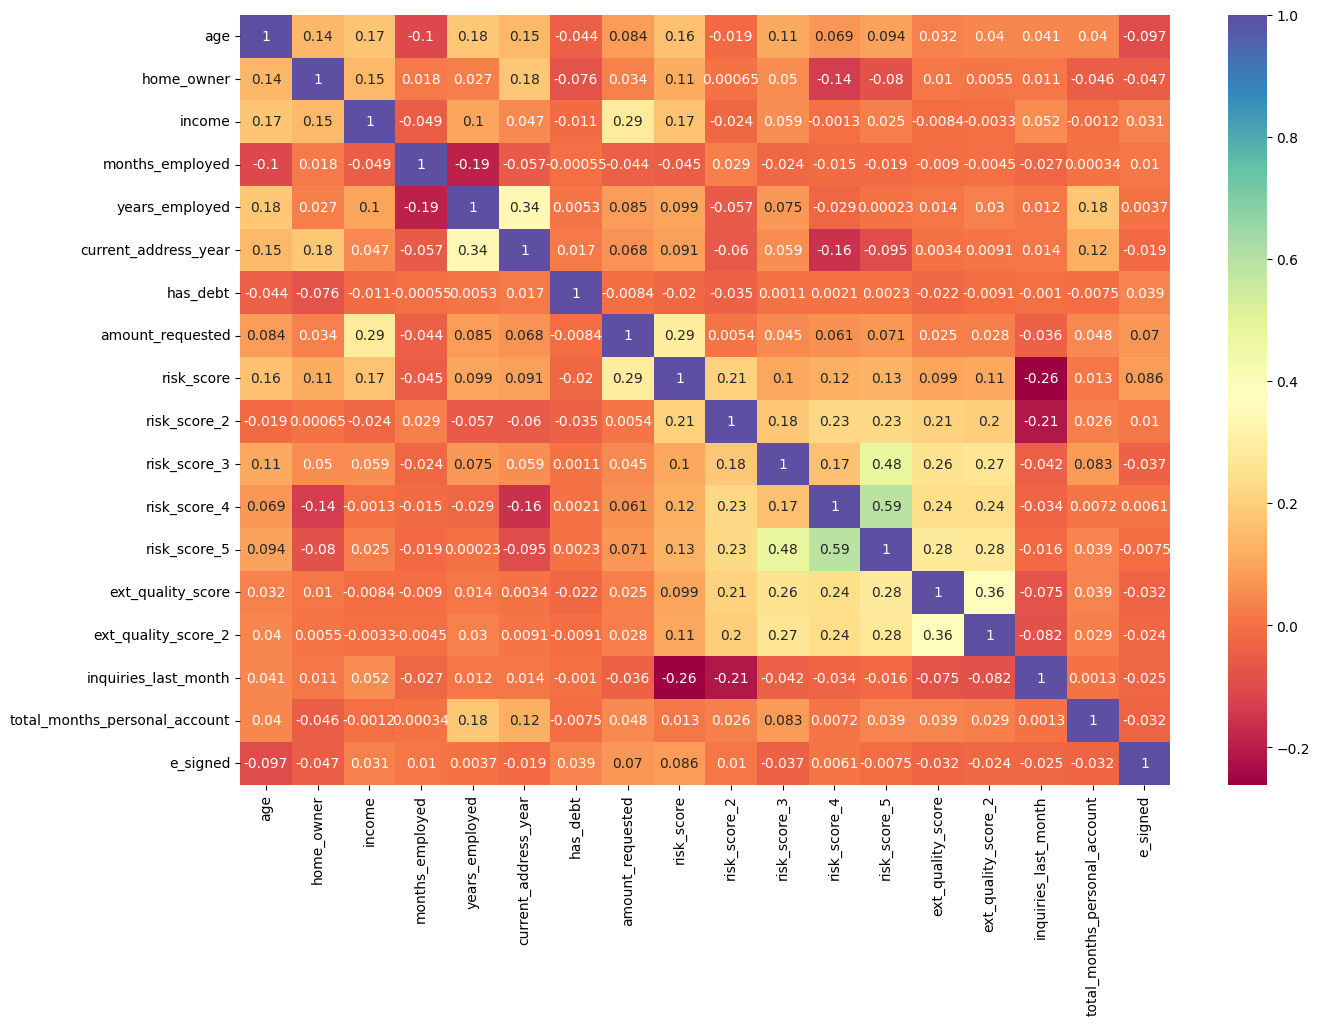

In [108]:
plt.figure(figsize=(15,10))
sns.heatmap(data=df_corr.corr(), cmap='Spectral', annot=True)

## 4. Preparation for Modeling

## 4.1 Convert Categorical Columns with OneHotEncoder

In [109]:
encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded_cats = encoder.fit_transform(df[categorical_cols])
encoded_cat_names = encoder.get_feature_names_out(categorical_cols)
df_encoded_cats = pd.DataFrame(encoded_cats, columns=encoded_cat_names, index=df.index)

In [110]:
df.head()

,entry_id,age,pay_schedule,home_owner,income,months_employed,years_employed,current_address_year,has_debt,amount_requested,risk_score,risk_score_2,risk_score_3,risk_score_4,risk_score_5,ext_quality_score,ext_quality_score_2,inquiries_last_month,e_signed,total_months_personal_account
0,7629673,40,bi-weekly,1,3135,0,3,3,1,550,36200,0.737398,0.903517,0.487712,0.515977,0.580918,0.380918,10,1,30
1,3560428,61,weekly,0,3180,0,6,3,1,600,30150,0.738510,0.881027,0.713423,0.826402,0.730720,0.630720,9,0,86
2,6934997,23,weekly,0,1540,6,0,0,1,450,34550,0.642993,0.766554,0.595018,0.762284,0.531712,0.531712,7,0,19
3,5682812,40,bi-weekly,0,5230,0,6,1,1,700,42150,0.665224,0.960832,0.767828,0.778831,0.792552,0.592552,8,1,86
4,5335819,33,semi-monthly,0,3590,0,5,2,1,1100,53850,0.617361,0.857560,0.613487,0.665523,0.744634,0.744634,12,0,98


## 4.2 Split Train And Test Datasets

In [111]:
X.head()

,age,home_owner,income,current_address_year,has_debt,amount_requested,risk_score,risk_score_2,risk_score_3,risk_score_4,risk_score_5,ext_quality_score,ext_quality_score_2,inquiries_last_month,total_months_personal_account,employed_month,pay_schedule_monthly,pay_schedule_semi-monthly,pay_schedule_weekly
0,40,1,3135,3,1,550,36200,0.737398,0.903517,0.487712,0.515977,0.580918,0.380918,10,30,3,0.0,0.0,0.0
1,61,0,3180,3,1,600,30150,0.738510,0.881027,0.713423,0.826402,0.730720,0.630720,9,86,6,0.0,0.0,1.0
2,23,0,1540,0,1,450,34550,0.642993,0.766554,0.595018,0.762284,0.531712,0.531712,7,19,72,0.0,0.0,1.0
3,40,0,5230,1,1,700,42150,0.665224,0.960832,0.767828,0.778831,0.792552,0.592552,8,86,6,0.0,0.0,0.0
4,33,0,3590,2,1,1100,53850,0.617361,0.857560,0.613487,0.665523,0.744634,0.744634,12,98,5,0.0,1.0,0.0


In [112]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=39)
X_train.reset_index(drop=True, inplace=True)
X_test.reset_index(drop=True, inplace=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

## 4.3 Scaling Numerical Columns

In [113]:
scaler = StandardScaler()

In [119]:
# Redefine numeric_cols to reflect the actual numeric columns in X_train
# X_train contains the original numeric columns and the one-hot encoded columns.
# We want to scale only the original numeric columns.
# The `encoded_cat_names` variable contains the names of the one-hot encoded columns.
current_numeric_cols_for_scaling = [col for col in X_train.columns if col not in encoded_cat_names]

scaler = StandardScaler()
X_train[current_numeric_cols_for_scaling] = pd.DataFrame(scaler.fit_transform(X_train[current_numeric_cols_for_scaling]), columns=current_numeric_cols_for_scaling)
X_test[current_numeric_cols_for_scaling] = pd.DataFrame(scaler.transform(X_test[current_numeric_cols_for_scaling]), columns=current_numeric_cols_for_scaling)

## 5. Model Building

## 5.1 Random Forest Classifier

##5.1.1 Initial Trial

In [121]:
rfc = RandomForestClassifier(random_state=39).fit(X_train, y_train)

In [123]:
y_pred = rfc.predict(X_test)

## 5.1.2 Model Evaluation

In [124]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.6280
Precision: 0.6414
Recall: 0.6872
ROC AUC Score: 0.6237

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.56      0.58      2505
           1       0.64      0.69      0.66      2868

    accuracy                           0.63      5373
   macro avg       0.63      0.62      0.62      5373
weighted avg       0.63      0.63      0.63      5373



# 6. Learning Curve of Max Depth

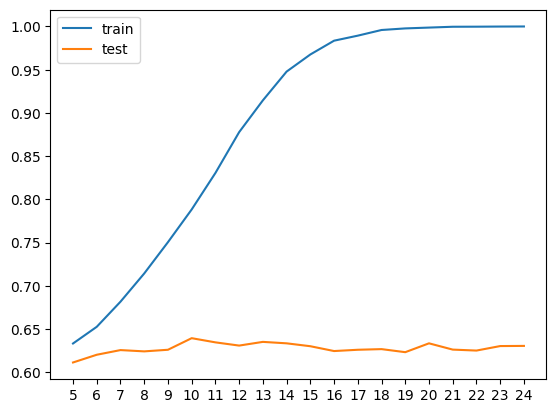

In [125]:
train_score = []
test_score = []

for i in range(5, 25):
    rfc = RandomForestClassifier(random_state=39, max_depth=i).fit(X_train, y_train)
    train_score.append(accuracy_score(y_train, rfc.predict(X_train)))
    test_score.append(accuracy_score(y_test, rfc.predict(X_test)))

plt.plot(range(5, 25), train_score, label='train')
plt.plot(range(5, 25), test_score, label='test')
plt.xticks(range(5, 25))
plt.legend()
plt.show()

## 6.1.1 Cross Validation

In [128]:
rfc = RandomForestClassifier(max_depth=10, random_state=41)
cross_val_score(rfc, X_train, y_train, cv=5).mean()

np.float64(0.6280813721579577)